# 04 Central Bank Policy

**Book:** *Global Macro Trading \u2014 Profiting in a New World Economy*  
**Focus:** Compute a simple Fed policy gap defined as `DFEDTARU - T10Y2Y`, then compare it to DXY and SPY behavior.


## Goals

1. Load Fed target, curve slope, and selected market proxies from the local parquet lake.
2. Compute the requested `fed_policy_gap = DFEDTARU - T10Y2Y` series.
3. Build a rolling z-score and simple daily-change comparison against SPY and DXY returns.
4. Save the daily policy-gap panel for reuse in the rest of the study.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-27_global_macro_trading_gliner"
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"
START = "2024-02-26"
END = "2026-02-27"
POLICY_GAP_CSV = STUDY_DIR / "04_fed_policy_gap_panel.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]


def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
fred_panel = load_fred_series(["DFEDTARU", "T10Y2Y", "SOFR", "DGS10"])
price_panel = load_local_price_series(["SPY", "DX-Y.NYB"])

business_days = pd.date_range(START, END, freq="B")
policy_panel = fred_panel.join(price_panel, how="outer").reindex(business_days).ffill().dropna().copy()
policy_panel.index.name = "date"

policy_panel["fed_policy_gap"] = policy_panel["DFEDTARU"] - policy_panel["T10Y2Y"]
policy_panel["policy_gap_z"] = (
    (policy_panel["fed_policy_gap"] - policy_panel["fed_policy_gap"].rolling(60, min_periods=20).mean())
    / policy_panel["fed_policy_gap"].rolling(60, min_periods=20).std(ddof=1)
)
policy_panel["gap_chg"] = policy_panel["fed_policy_gap"].diff()
policy_panel["spy_ret"] = np.log(policy_panel["SPY"]).diff()
policy_panel["dxy_ret"] = np.log(policy_panel["DX-Y.NYB"]).diff()

analysis_panel = policy_panel[["DFEDTARU", "T10Y2Y", "SOFR", "DGS10", "SPY", "DX-Y.NYB", "fed_policy_gap", "policy_gap_z", "gap_chg", "spy_ret", "dxy_ret"]].dropna()
analysis_panel.tail()


            DFEDTARU  T10Y2Y  SOFR  DGS10         SPY   DX-Y.NYB  fed_policy_gap  policy_gap_z  gap_chg   spy_ret   dxy_ret
date                                                                                                                       
2026-02-23      3.75    0.60  3.66   4.03  682.390015  97.699997            3.15      0.296226     0.00 -0.010264 -0.001023
2026-02-24      3.75    0.61  3.67   4.03  687.349976  97.879997            3.14      0.266469    -0.01  0.007242  0.001841
2026-02-25      3.75    0.60  3.67   4.05  693.150024  97.699997            3.15      0.432787     0.01  0.008403 -0.001841
2026-02-26      3.75    0.60  3.67   4.05  689.299988  97.790001            3.15      0.516201     0.00 -0.005570  0.000921
2026-02-27      3.75    0.59  3.67   4.05  685.989990  97.646004            3.16      0.745463     0.01 -0.004814 -0.001474

In [4]:
policy_summary = analysis_panel[["fed_policy_gap", "policy_gap_z"]].describe().round(3)
market_link = analysis_panel[["gap_chg", "spy_ret", "dxy_ret"]].corr().round(3)
peak_gap_dates = analysis_panel["fed_policy_gap"].nlargest(10).rename("fed_policy_gap")

print(policy_summary.to_string())
print(market_link.to_string())
peak_gap_dates.head(10)


       fed_policy_gap  policy_gap_z
count         506.000       506.000
mean            4.420        -1.000
std             0.911         1.101
min             3.010        -4.635
25%             3.910        -1.645
50%             4.155        -1.044
75%             5.425        -0.413
max             5.970         2.250
         gap_chg  spy_ret  dxy_ret
gap_chg    1.000    0.129    0.090
spy_ret    0.129    1.000    0.074
dxy_ret    0.090    0.074    1.000


date
2024-05-24    5.97
2024-05-27    5.97
2024-06-14    5.97
2024-06-17    5.97
2024-06-18    5.97
2024-06-19    5.97
2024-06-24    5.96
2024-06-20    5.95
2024-06-21    5.95
2024-05-23    5.94

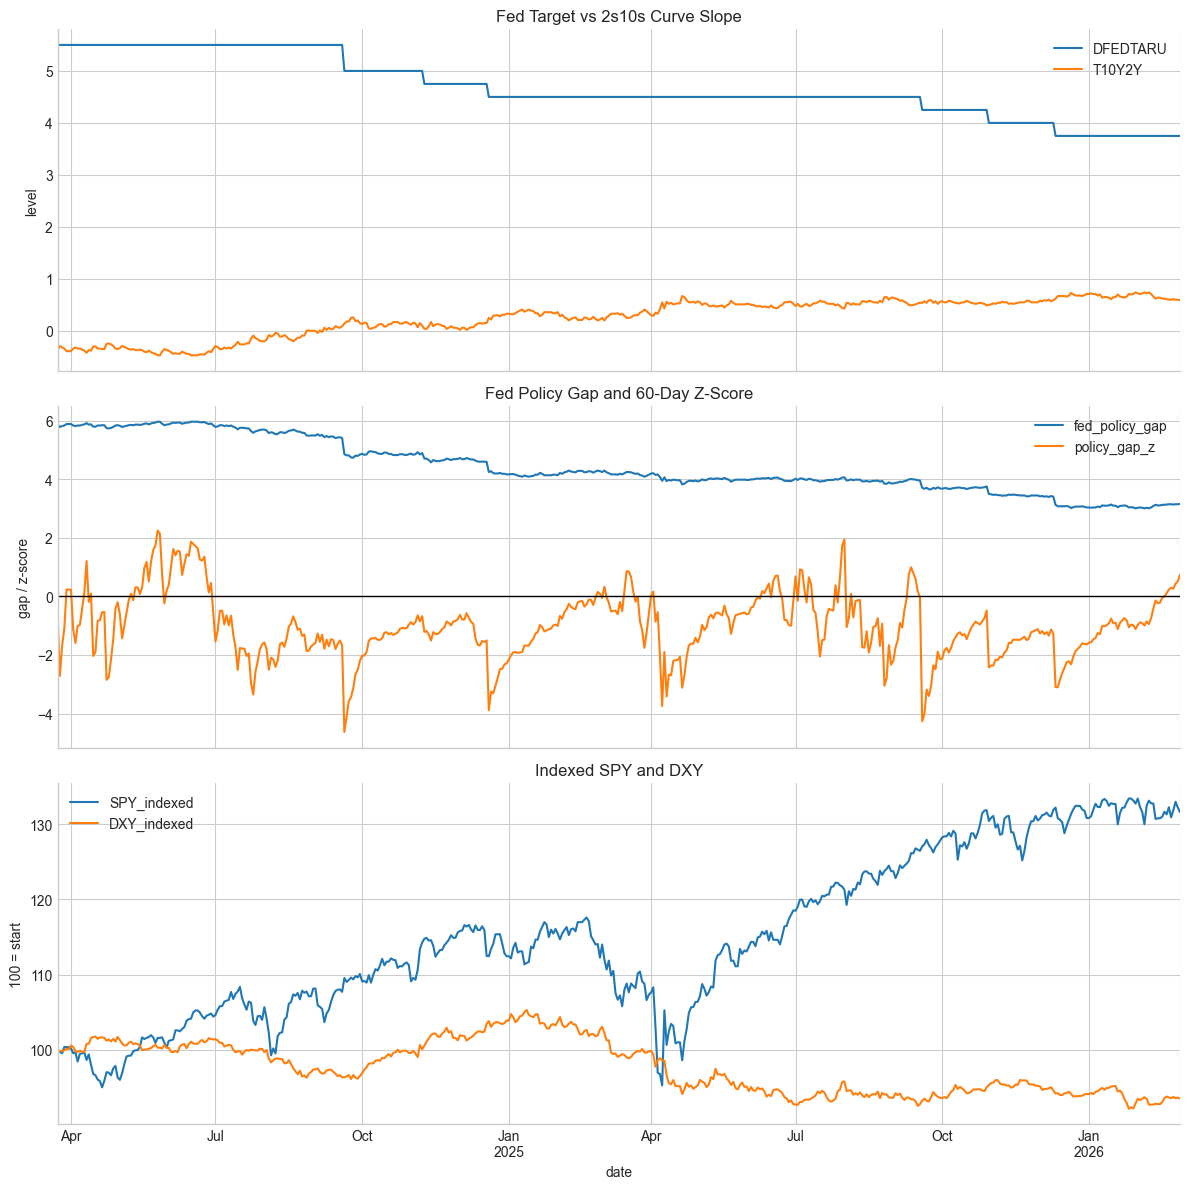

In [5]:
normalized_prices = pd.DataFrame(index=analysis_panel.index)
normalized_prices["SPY_indexed"] = analysis_panel["SPY"] / analysis_panel["SPY"].iloc[0] * 100.0
normalized_prices["DXY_indexed"] = analysis_panel["DX-Y.NYB"] / analysis_panel["DX-Y.NYB"].iloc[0] * 100.0

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

analysis_panel[["DFEDTARU", "T10Y2Y"]].plot(ax=axes[0], title="Fed Target vs 2s10s Curve Slope")
axes[0].set_ylabel("level")

analysis_panel[["fed_policy_gap", "policy_gap_z"]].plot(ax=axes[1], title="Fed Policy Gap and 60-Day Z-Score")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_ylabel("gap / z-score")

normalized_prices.plot(ax=axes[2], title="Indexed SPY and DXY")
axes[2].set_ylabel("100 = start")

plt.tight_layout()
plt.show()


In [6]:
analysis_panel.to_csv(POLICY_GAP_CSV)
print("saved Fed policy gap panel to", POLICY_GAP_CSV)
analysis_panel.tail()


saved Fed policy gap panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/04_fed_policy_gap_panel.csv


            DFEDTARU  T10Y2Y  SOFR  DGS10         SPY   DX-Y.NYB  fed_policy_gap  policy_gap_z  gap_chg   spy_ret   dxy_ret
date                                                                                                                       
2026-02-23      3.75    0.60  3.66   4.03  682.390015  97.699997            3.15      0.296226     0.00 -0.010264 -0.001023
2026-02-24      3.75    0.61  3.67   4.03  687.349976  97.879997            3.14      0.266469    -0.01  0.007242  0.001841
2026-02-25      3.75    0.60  3.67   4.05  693.150024  97.699997            3.15      0.432787     0.01  0.008403 -0.001841
2026-02-26      3.75    0.60  3.67   4.05  689.299988  97.790001            3.15      0.516201     0.00 -0.005570  0.000921
2026-02-27      3.75    0.59  3.67   4.05  685.989990  97.646004            3.16      0.745463     0.01 -0.004814 -0.001474